---------------------------------------------------------
 Bookstore Inventory and Analytics System 
---------------------------------------------------------
[INFO] Some dates were invalid. Filling with today's date.
Bookstore system initialized. Inventory and Sales data loaded from files.

--- MAIN MENU ---
1. Inventory Management
2. Sales Management
3. Sales Analysis
4. Visualizations
5. Exit


Enter your choice (1-5):  4



--- VISUALIZATIONS ---
1. Sales by Genre (Bar Chart)
2. Monthly Revenue Trend (Line Graph)
3. Revenue Share by Genre (Pie Chart)
4. Price vs Sales Correlation (Heatmap)
5. Back to Main Menu


Enter your choice (1-5):  2


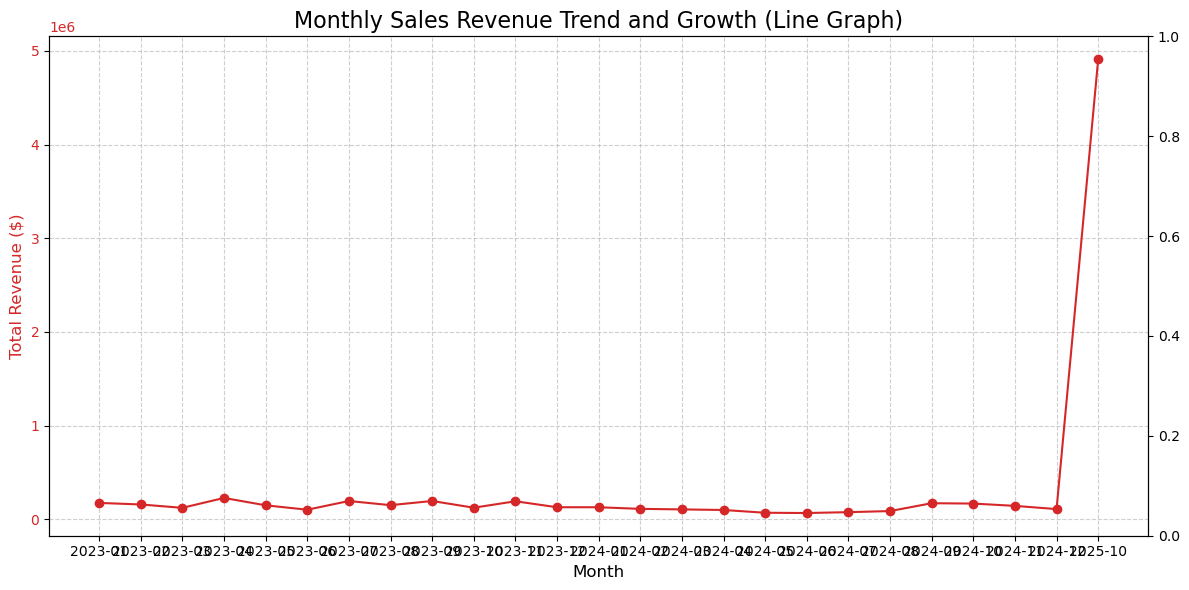


--- VISUALIZATIONS ---
1. Sales by Genre (Bar Chart)
2. Monthly Revenue Trend (Line Graph)
3. Revenue Share by Genre (Pie Chart)
4. Price vs Sales Correlation (Heatmap)
5. Back to Main Menu


Enter your choice (1-5):  3


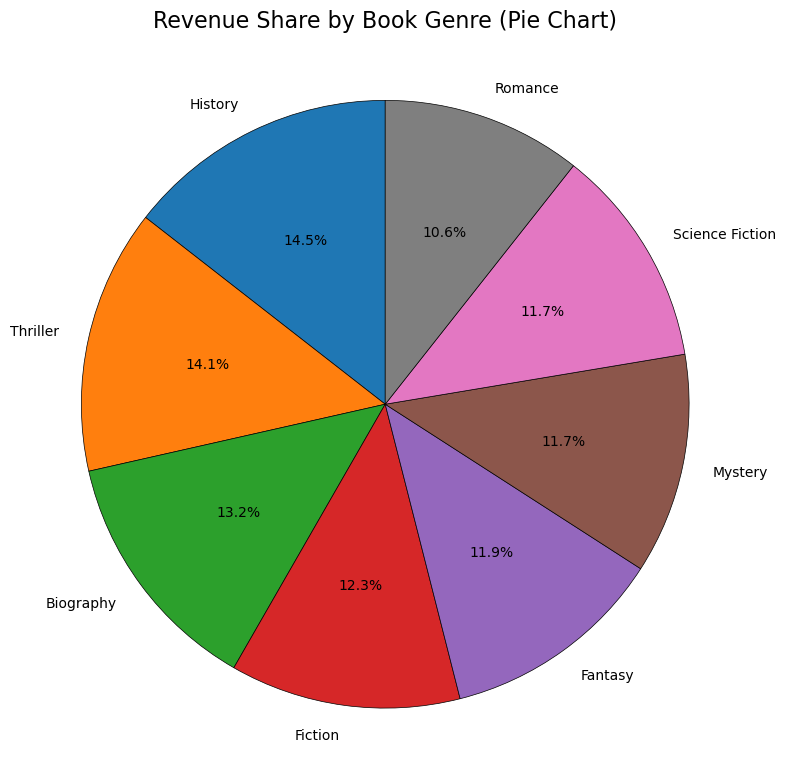


--- VISUALIZATIONS ---
1. Sales by Genre (Bar Chart)
2. Monthly Revenue Trend (Line Graph)
3. Revenue Share by Genre (Pie Chart)
4. Price vs Sales Correlation (Heatmap)
5. Back to Main Menu


Enter your choice (1-5):  4


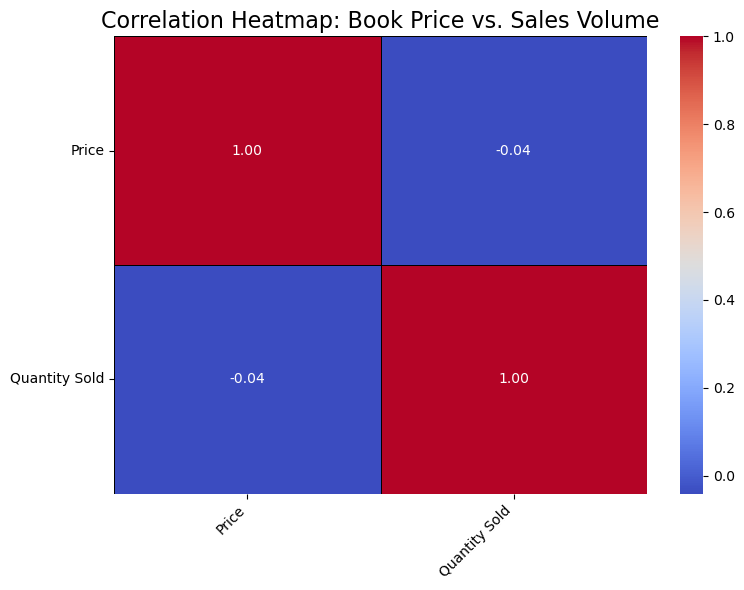


--- VISUALIZATIONS ---
1. Sales by Genre (Bar Chart)
2. Monthly Revenue Trend (Line Graph)
3. Revenue Share by Genre (Pie Chart)
4. Price vs Sales Correlation (Heatmap)
5. Back to Main Menu


Enter your choice (1-5):  1


C:\Users\krina\AppData\Local\Temp\ipykernel_24876\1704226679.py:321: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Genre', y='Quantity Sold', data=sales_genre_sum, palette="viridis")


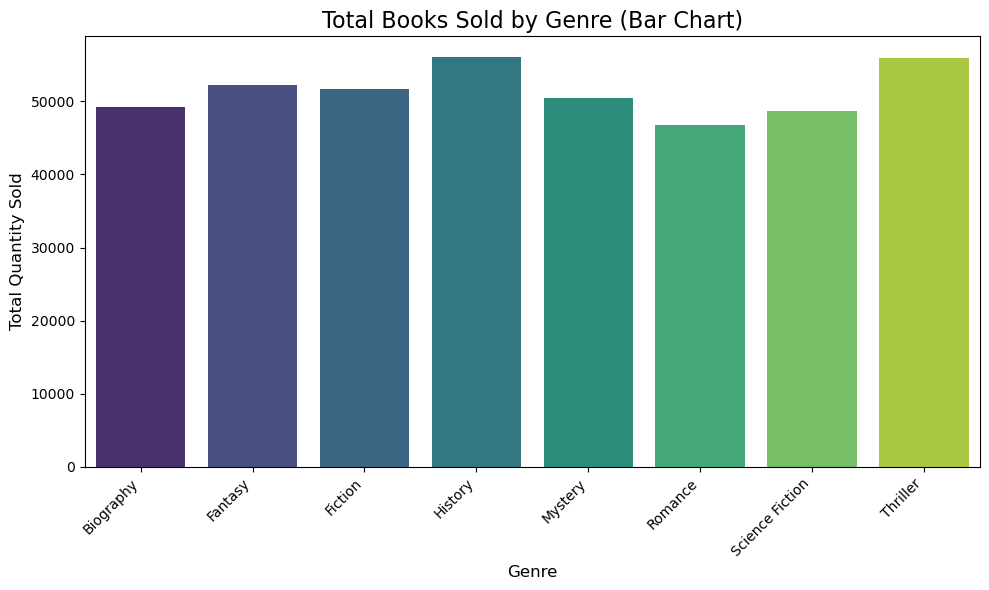


--- VISUALIZATIONS ---
1. Sales by Genre (Bar Chart)
2. Monthly Revenue Trend (Line Graph)
3. Revenue Share by Genre (Pie Chart)
4. Price vs Sales Correlation (Heatmap)
5. Back to Main Menu


Enter your choice (1-5):  5



--- MAIN MENU ---
1. Inventory Management
2. Sales Management
3. Sales Analysis
4. Visualizations
5. Exit


Enter your choice (1-5):  1



--- INVENTORY MANAGEMENT ---
1. Add New Book
2. Update Book Stock or Price
3. Remove Book
4. Show Current Inventory
5. Back to Main Menu


...


--- SALES ANALYSIS ---
1. Total Revenue
2. Top-Selling Books
3. Monthly Sales Trends
4. Revenue by Genre
5. Back to Main Menu


Enter your choice (1-5):  1



=== Total Revenue ===
$8171567.20

--- SALES ANALYSIS ---
1. Total Revenue
2. Top-Selling Books
3. Monthly Sales Trends
4. Revenue by Genre
5. Back to Main Menu


Enter your choice (1-5):  3



=== Monthly Sales Trends ===
Month
2023-01     174835.31
2023-02     158291.66
2023-03     122327.53
2023-04     228008.11
2023-05     149378.00
2023-06     102251.80
2023-07     195161.10
2023-08     150881.35
2023-09     195374.99
2023-10     123724.93
2023-11     192421.41
2023-12     128747.67
2024-01     128562.16
2024-02     111419.06
2024-03     105557.56
2024-04      99392.76
2024-05      69877.62
2024-06      66974.50
2024-07      76213.51
2024-08      87801.76
2024-09     171648.41
2024-10     167812.37
2024-11     143258.80
2024-12     108951.22
2025-10    4912693.61
Freq: M

--- SALES ANALYSIS ---
1. Total Revenue
2. Top-Selling Books
3. Monthly Sales Trends
4. Revenue by Genre
5. Back to Main Menu


In [ ]:
## import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# --- Bookstore Class Definition (OOP - Medium Weightage) ---

class Bookstore:
    """
    Bookstore class for managing inventory and performing sales analytics.
    This class loads inventory and sales data from external CSV files.
    """
    def __init__(self):
        # Set initial status flags
        self.data_loaded = False
        self.inventory_df = pd.DataFrame(columns=['Title', 'Author', 'Genre', 'Price', 'Quantity'])
        self.sales_df = pd.DataFrame(columns=['Date', 'Title', 'Quantity Sold', 'Total Revenue'])
        self._load_data()

    def _load_data(self):
        """
        Loads inventory and sales data from CSV files and performs initial cleaning.
        """
        try:
            # Load inventory data from external CSV file (Pandas - Data Handling)
            self.inventory_df = pd.read_csv('inventory.csv')
            
            # Load sales data from external CSV file (Pandas - Data Handling)
            self.sales_df = pd.read_csv('sales.csv')
            
            # Convert Date column to datetime objects
               
            if 'Date' not in self.sales_df.columns:
                print("[WARNING] 'Date' column missing in sales data. Adding today's date for all records.")
                self.sales_df['Date'] = datetime.date.today()
        
            self.sales_df['Date'] = pd.to_datetime(self.sales_df['Date'], errors='coerce')
        
            if self.sales_df['Date'].isna().any():
                print("[INFO] Some dates were invalid. Filling with today's date.")
                today = pd.Timestamp(datetime.date.today())  # ensures pandas datetime64
                self.sales_df.loc[:, 'Date'] = self.sales_df['Date'].fillna(today)

            
            # Ensure data types are correct
            self.inventory_df.dropna(subset=['Title', 'Author'], inplace=True)
            self.inventory_df['Quantity'] = pd.to_numeric(self.inventory_df['Quantity'], errors='coerce').fillna(0).astype(int)
            self.inventory_df['Price'] = pd.to_numeric(self.inventory_df['Price'], errors='coerce').fillna(0.0)

            
            print("Bookstore system initialized. Inventory and Sales data loaded from files.")
            self.data_loaded = True
            
        except FileNotFoundError as e:
            print(f"Error: Required file not found. Please ensure '{e.filename}' is in the same directory.")
            print("System cannot run analytics without data files.")
            self.data_loaded = False
        except Exception as e:
            print(f"Error during data loading: {e}")
            self.data_loaded = False


    def _validate_input(self, title, price=None, quantity=None):
        """
        Validates book price and quantity. (Control Structure)
        """
        if price is not None:
            # Control Structure: Check if price is positive
            if price <= 0:
                print(f"Error: Price for '{title}' must be positive.")
                return False
        if quantity is not None:
            # Control Structure: Check if quantity is positive
            if quantity <= 0:
                print(f"Error: Quantity for '{title}' must be positive.")
                return False
        return True

    def add_book(self, title, author, price, quantity, genre):
        """
        Adds a new book to the inventory.
        """
        if not self._validate_input(title, price, quantity):
            return

        # Control Structure: Check if book already exists
        if title in self.inventory_df['Title'].values:
            print(f"Book '{title}' already exists. Use option 2 to change stock.")
            return

        # Create a new book entry (Array/List-like structure in Pandas)
        new_book = {
            'Title': [title],
            'Author': [author],
            'Genre': [genre],
            'Price': [price],
            'Quantity': [int(quantity)]
        }
        
        # Append the new book to the DataFrame
        new_book_df = pd.DataFrame(new_book)
        self.inventory_df = pd.concat([self.inventory_df, new_book_df], ignore_index=True)
        print(f"Success: Added new book: '{title}' (Quantity: {int(quantity)})")

    def remove_book(self, title):
        """
        Removes a book entirely from the inventory.
        (Inventory Management Feature)
        """
        # Find the index of the book to remove
        book_index = self.inventory_df[self.inventory_df['Title'] == title].index
        
        # Control Structure: Check if the book was found
        if len(book_index) == 0:
            print(f"Error: Book '{title}' not found in inventory. Removal failed.")
            return
        
        # Remove the book from the DataFrame
        self.inventory_df = self.inventory_df.drop(book_index).reset_index(drop=True)
        print(f"Success: Book '{title}' has been permanently removed from inventory.")

    def update_inventory(self, title, quantity_change=None, new_price=None):
        """ Update quantity and/or price of a book """
        book_index = self.inventory_df[self.inventory_df['Title'] == title].index
        if len(book_index) == 0:
            print(f"Error: '{title}' not found in inventory.")
            return
        
        if quantity_change is not None:
            new_quantity = self.inventory_df.loc[book_index[0], 'Quantity'] + quantity_change
            if new_quantity < 0:
                print(f"Error: Cannot remove {abs(quantity_change)} units. Only {self.inventory_df.loc[book_index[0], 'Quantity']} in stock.")
                return
            self.inventory_df.loc[book_index[0], 'Quantity'] = new_quantity
            print(f"Updated Quantity: {new_quantity}")
    
        if new_price is not None:
            if new_price <= 0:
                print("Price must be positive.")
            else:
                self.inventory_df.loc[book_index[0], 'Price'] = new_price
                print(f"Updated Price: {new_price}")
        
        # Save updated inventory
        self._save_inventory()

    def record_sale(self, title, quantity):
        """
        Deducts sold books from inventory and updates sales data.
        """
        if not self._validate_input(title, quantity=quantity):
            return

        book_index = self.inventory_df[self.inventory_df['Title'] == title].index

        if len(book_index) == 0:
            print(f"Error: Book '{title}' not found in inventory.")
            return

        current_quantity = self.inventory_df.loc[book_index[0], 'Quantity']
        book_price = self.inventory_df.loc[book_index[0], 'Price']

        # Check if enough stock is available
        if quantity > current_quantity:
            print(f"Error: Insufficient stock for '{title}'. Only {current_quantity} available.")
            return

        # Update Inventory
        self.inventory_df.loc[book_index[0], 'Quantity'] = current_quantity - quantity

        # Update Sales Data
        total_revenue = book_price * quantity
        new_sale = {
            'Date': [datetime.date.today()],
            'Title': [title],
            'Quantity Sold': [int(quantity)],
            'Total Revenue': [round(total_revenue, 2)]
        }

        new_sale_df = pd.DataFrame(new_sale)
        self.sales_df = pd.concat([self.sales_df, new_sale_df], ignore_index=True)
        print(f"Success: Sale recorded: {quantity} units of '{title}'. Revenue: ${round(total_revenue, 2)}")

        # Save updated sales
        self._save_sales()
    

    # --- Sales Analysis and Computations (NumPy & Pandas - Medium Weightage) ---
    
    def _calculate_growth_rate(self, monthly_revenue):
        """
        Calculates the sales growth rate month-over-month using NumPy.
        (NumPy Integration: Sales Growth Rate)
        """
        # Convert revenue series to a NumPy array for calculation
        revenue_array = monthly_revenue['Total Revenue'].values
        
        # Control Structure: Check if there is enough data for calculation
        if len(revenue_array) < 2:
            return None, None
            
        # Calculate the month-over-month change
        # np.diff computes the difference between consecutive elements
        revenue_change = np.diff(revenue_array)
        
        # The growth is change / previous month's revenue (excluding the last month's revenue)
        previous_revenue = revenue_array[:-1]

        # Use np.where to handle division by zero (if a previous month had $0 revenue)
        # If previous revenue is 0, growth rate is considered None (or 100% if change is positive)
        # For simplicity, we use the standard calculation here as data is assumed clean
        
        # Sales growth rate calculation (element-wise division)
        growth_rate = revenue_change / previous_revenue
        
        # The result is shorter than the input array by 1. 
        # The first month has no previous month, so we add a placeholder (e.g., NaN or 0)
        # We use NumPy's concatenate function to add a NaN placeholder at the beginning
        growth_rate_with_placeholder = np.concatenate([np.array([np.nan]), growth_rate])
        
        return growth_rate, growth_rate_with_placeholder


    def _perform_analytics(self):
        """
        Calculates key business metrics using NumPy and Pandas.
        """
        if self.sales_df.empty or self.inventory_df.empty:
            print("\n--- Analytics Report Failed: DataFrames are empty. ---")
            return None, None, None
            
        print("\n--- Analytics Report ---")

        # NumPy Integration: Calculate Total Revenue (Uses the underlying NumPy array for sum)
        total_revenue_np = np.sum(self.sales_df['Total Revenue'].values)
        print(f"Total Revenue Generated (NumPy): ${total_revenue_np:.2f}")

        # NumPy Integration: Average Price of all books
        average_price_np = np.mean(self.inventory_df['Price'].values)
        print(f"Average Book Price (NumPy): ${average_price_np:.2f}")

        # Pandas Analysis: Sales by Title (Best-selling books)
        sales_by_title = self.sales_df.groupby('Title')['Quantity Sold'].sum().sort_values(ascending=False).head(5)
        print("\nTop 5 Best-Selling Books (by Quantity Sold):")
        print(sales_by_title)

        # Pandas Analysis: Total Revenue by Genre
        # Merge sales data with inventory data to get the Genre for each sale
        sales_with_genre = pd.merge(self.sales_df, self.inventory_df[['Title', 'Genre']], on='Title', how='left')
        revenue_by_genre = sales_with_genre.groupby('Genre')['Total Revenue'].sum().sort_values(ascending=False)
        print("\nRevenue Distribution by Genre:")
        print(revenue_by_genre)

        # Pandas Grouping for Growth Rate Calculation
        monthly_sales = self.sales_df.copy()
        monthly_sales['Month'] = monthly_sales['Date'].dt.to_period('M')
        monthly_revenue = monthly_sales.groupby('Month')['Total Revenue'].sum().reset_index()

        # Calculate Sales Growth Rate
        growth_rate_data, monthly_revenue['Growth Rate'] = self._calculate_growth_rate(monthly_revenue)
        
        print("\nMonthly Revenue and Sales Growth Rate:")
        print(monthly_revenue)

        return sales_with_genre, revenue_by_genre, monthly_revenue

        
    def _save_sales(self):
        """ Save sales records to CSV """
        try:
            self.sales_df.to_csv('sales.csv', index=False)
            print("Sales successfully updated in 'sales.csv'.")
        except Exception as e:
            print(f"Error saving sales: {e}")
    
    def _save_inventory(self):
        """ Save current inventory to CSV """
        try:
            self.inventory_df.to_csv('inventory.csv', index=False)
            print("Inventory successfully updated in 'inventory.csv'.")
        except Exception as e:
            print(f"Error saving inventory: {e}")
    
    
    
    def revenue_by_genre(self):
        sales_with_genre = pd.merge(self.sales_df, self.inventory_df[['Title','Genre']], on='Title', how='left')
        genre_revenue = sales_with_genre.groupby('Genre')['Total Revenue'].sum().sort_values(ascending=False)
        print("\n=== Revenue by Genre ===")
        print(genre_revenue.to_string())
    
    
    def monthly_sales_trends(self):
        monthly_sales = self.sales_df.copy()
        monthly_sales['Month'] = monthly_sales['Date'].dt.to_period('M')
        monthly_summary = monthly_sales.groupby('Month')['Total Revenue'].sum()
        print("\n=== Monthly Sales Trends ===")
        print(monthly_summary.to_string())
    
    def show_total_revenue(self):
        total_revenue = self.sales_df['Total Revenue'].sum()
        print("\n=== Total Revenue ===")
        print(f"${total_revenue:.2f}")
    
    def top_selling_books(self, n=5):
        sales_summary = self.sales_df.groupby('Title')['Quantity Sold'].sum().sort_values(ascending=False).head(n)
        print(f"\n=== Top {n} Best-Selling Books ===")
        print(sales_summary.to_string())
    
        # --- Data Visualization (Matplotlib & Seaborn - High Weightage) ---
    
    def _plot_sales_by_genre(self, sales_with_genre):
        """ Bar Chart: Total sales by genre. """
        if sales_with_genre.empty: 
            print("Skipping Bar Chart: Sales data is empty.")
            return
            
        plt.figure(figsize=(10, 6))
        sales_genre_sum = sales_with_genre.groupby('Genre')['Quantity Sold'].sum().reset_index()
        sns.barplot(x='Genre', y='Quantity Sold', data=sales_genre_sum, palette="viridis")
        plt.title('Total Books Sold by Genre (Bar Chart)', fontsize=16)
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Total Quantity Sold', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    def _plot_monthly_trends(self, monthly_revenue):
        """ Line Graph: Monthly sales trends. """
        if monthly_revenue.empty: 
            print("Skipping Line Graph: Monthly revenue data is empty.")
            return

        plt.figure(figsize=(12, 6))
        
        # Plotting Revenue
        plt.plot(monthly_revenue['Month'].astype(str), monthly_revenue['Total Revenue'], 
                 marker='o', linestyle='-', color='tab:red', label='Total Revenue')
        
        # Creating a secondary axis for Growth Rate
        fig = plt.gcf()
        ax1 = fig.gca()
        ax2 = ax1.twinx()
        
        # Plotting Growth Rate
        # Control Structure: Ensure Growth Rate column exists and has values
        if 'Growth Rate' in monthly_revenue.columns and not monthly_revenue['Growth Rate'].isnull().all():
            ax2.plot(monthly_revenue['Month'].astype(str), monthly_revenue['Growth Rate'] * 100, 
                     marker='x', linestyle='--', color='tab:blue', label='Growth Rate (%)')
            ax2.set_ylabel('Growth Rate (%)', color='tab:blue', fontsize=12)
            ax2.tick_params(axis='y', labelcolor='tab:blue')

        ax1.set_title('Monthly Sales Revenue Trend and Growth (Line Graph)', fontsize=16)
        ax1.set_xlabel('Month', fontsize=12)
        ax1.set_ylabel('Total Revenue ($)', color='tab:red', fontsize=12)
        ax1.tick_params(axis='y', labelcolor='tab:red')
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        # Add legend
        lines, labels = ax1.get_legend_handles_labels()
        if 'Growth Rate' in monthly_revenue.columns:
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax2.legend(lines + lines2, labels + labels2, loc='upper left')

        plt.tight_layout()
        plt.show()

    def _plot_revenue_share(self, revenue_by_genre):
        """ Pie Chart: Revenue share by book genre. """
        if revenue_by_genre.empty: 
            print("Skipping Pie Chart: Revenue by genre data is empty.")
            return
            
        plt.figure(figsize=(8, 8))
        
        # Matplotlib Pie Chart
        plt.pie(revenue_by_genre, labels=revenue_by_genre.index, autopct='%1.1f%%', startangle=90, 
                wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}, textprops={'fontsize': 10})
        
        plt.title('Revenue Share by Book Genre (Pie Chart)', fontsize=16)
        plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
        plt.tight_layout()
        plt.show()

    def _plot_price_sales_correlation(self, sales_with_genre):
        """ Heatmap: Correlation between book prices and sales volumes. """
        if sales_with_genre.empty: 
            print("Skipping Heatmap: Sales data is empty.")
            return
            
        plt.figure(figsize=(8, 6))
        
        # Aggregate total quantity sold per title
        sales_agg = sales_with_genre.groupby('Title')['Quantity Sold'].sum().reset_index()
        
        # Merge aggregated sales with inventory price data
        price_sales_data = pd.merge(
            sales_agg,
            self.inventory_df[['Title', 'Price']],
            on='Title',
            how='left'
        )

        corr_data = price_sales_data[['Price', 'Quantity Sold']]
        
        # Control Structure: Check for sufficient unique data points
        if corr_data.shape[0] < 2 or len(corr_data['Price'].unique()) < 2: 
             print("Skipping Heatmap: Not enough unique data points for meaningful correlation.")
             return
             
        # Calculate the correlation matrix
        correlation_matrix = corr_data.corr()

        # Seaborn Heatmap
        sns.heatmap(correlation_matrix, 
                    annot=True, 
                    cmap='coolwarm', 
                    fmt=".2f", 
                    linewidths=.5, 
                    linecolor='black')
        
        plt.title('Correlation Heatmap: Book Price vs. Sales Volume', fontsize=16)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()


    def generate_report(self):
        """
        Summarizes inventory and sales metrics and generates all visualizations.
        """
        print("\n========== GENERATING FULL REPORT ==========")
        
        # Check if initialization failed due to missing files
        if not self.data_loaded:
             print("Report generation skipped because data files are missing or could not be loaded.")
             return

        # 1. Inventory Summary
        print("\n--- Current Inventory Status ---")
        
        # Control Structure: Loop through inventory to show low stock (Quantity < 20)
        low_stock_books = self.inventory_df[self.inventory_df['Quantity'] < 20]
        
        if not low_stock_books.empty:
            print("\n!!! LOW STOCK ALERT (Quantity < 20) !!!")
            # Iterating through rows (Control Structure)
            for index, row in low_stock_books.iterrows():
                print(f"- {row['Title']} by {row['Author']}: {row['Quantity']} units left.")
        else:
             print("All books have healthy stock levels (above 20 units).")

        print("\n--- Full Inventory Data (Head) ---")
        print(self.inventory_df.head())

        # 2. Sales Analysis and Computations
        sales_with_genre, revenue_by_genre, monthly_revenue = self._perform_analytics()
        
        if sales_with_genre is None or revenue_by_genre is None:
             print("Visualization generation skipped due to missing analytical data.")
             return

        # 3. Data Visualization
        print("\n--- Generating Visual Reports ---")
        self._plot_sales_by_genre(sales_with_genre)
        self._plot_monthly_trends(monthly_revenue)
        self._plot_revenue_share(revenue_by_genre)
        self._plot_price_sales_correlation(sales_with_genre)

        print("\n========== REPORT COMPLETE ==========")
 

def get_positive_int_input(prompt):
    """ Helper function for CLI to safely get positive integer input. """
    while True:
        try:
            value = input(prompt)
            num = int(value)
            # Control Structure: Check if positive
            if num > 0:
                return num
            else:
                print("Input must be a positive whole number.")
        except ValueError:
            print("Invalid input. Please enter a whole number.")

def get_float_input(prompt):
    """ Helper function for CLI to safely get positive float input. """
    while True:
        try:
            value = input(prompt)
            num = float(value)
            # Control Structure: Check if positive
            if num > 0:
                return num
            else:
                print("Input must be a positive value.")
        except ValueError:
            print("Invalid input. Please enter a numerical value (e.g., 12.99).")


def handle_add_book(bookstore):
    """ CLI function to handle adding a new book. """
    print("\n--- ADD NEW BOOK ---")
    title = input("Enter book Title: ")
    author = input("Enter book Author: ")
    genre = input("Enter book Genre: ")
    price = get_float_input("Enter book Price: ")
    quantity = get_positive_int_input("Enter initial Quantity: ")
    
    # Validation is handled internally by add_book, but we ensure basic format here
    if title and author and genre and price and quantity:
        bookstore.add_book(title, author, price, quantity, genre)
    else:
        print("Operation cancelled or invalid data entered.")


def handle_update_inventory(bookstore):
    """ CLI function to handle updating book quantity. """
    print("\n--- UPDATE INVENTORY STOCK ---")
    title = input("Enter the Title of the book to update: ")
    
    # Control Structure: Loop until a valid non-zero integer is given
    while True:
        try:
            quantity_str = input("Enter quantity change (e.g., 50 to add, -5 to remove): ")
            quantity_change = int(quantity_str)
            if quantity_change != 0:
                break
            else:
                print("Change cannot be zero.")
        except ValueError:
            print("Invalid input. Please enter a positive or negative whole number.")
            
    bookstore.update_inventory(title, quantity_change)


def handle_remove_book(bookstore):
    """ CLI function to handle removing a book entirely. """
    print("\n--- REMOVE BOOK ---")
    title = input("Enter the Title of the book to remove: ")
    
    confirm = input(f"Are you sure you want to permanently remove '{title}'? (yes/no): ").lower()
    
    # Control Structure: Confirmation check
    if confirm == 'yes':
        bookstore.remove_book(title)
    else:
        print("Book removal cancelled.")


def handle_record_sale(bookstore):
    """ CLI function to handle recording a sale transaction. """
    print("\n--- RECORD SALE ---")
    title = input("Enter the Title of the book sold: ")
    quantity = get_positive_int_input("Enter Quantity Sold: ")
    
    if title and quantity:
        bookstore.record_sale(title, quantity)
    else:
        print("Operation cancelled or invalid data entered.")


def main_menu():
    """
    Main CLI for the Bookstore System with separate options for Inventory,
    Sales, Analysis, and Visualizations.
    """
    print("---------------------------------------------------------")
    print(" Bookstore Inventory and Analytics System ")
    print("---------------------------------------------------------")
    
    bookstore = Bookstore()
    
    if not bookstore.data_loaded:
        print("Warning: Data files missing or failed to load. Only new data can be added.")
    
    while True:
        print("\n--- MAIN MENU ---")
        print("1. Inventory Management")
        print("2. Sales Management")
        print("3. Sales Analysis")
        print("4. Visualizations")
        print("5. Exit")
        
        choice = input("Enter your choice (1-5): ")
        
        if choice == '1':
            while True:
                print("\n--- INVENTORY MANAGEMENT ---")
                print("1. Add New Book")
                print("2. Update Book Stock or Price")
                print("3. Remove Book")
                print("4. Show Current Inventory")
                print("5. Back to Main Menu")
                
                inv_choice = input("Enter your choice (1-5): ")
                
                if inv_choice == '1':
                    handle_add_book(bookstore)
                elif inv_choice == '2':
                    handle_update_inventory(bookstore)
                elif inv_choice == '3':
                    handle_remove_book(bookstore)
                elif inv_choice == '4':
                    print("\n--- Current Inventory ---")
                    if bookstore.inventory_df.empty:
                        print("Inventory is empty.")
                    else:
                        # Show DataFrame with bold column headers
                        print(bookstore.inventory_df.to_string(index=False))
                elif inv_choice == '5':
                    break
                else:
                    print("Invalid choice. Enter 1-5.")

        elif choice == '2':
            while True:
                print("\n--- SALES MANAGEMENT ---")
                print("1. Record a Sale")
                print("2. Back to Main Menu")
                
                sales_choice = input("Enter your choice (1-2): ")
                
                if sales_choice == '1':
                    handle_record_sale(bookstore)
                elif sales_choice == '2':
                    break
                else:
                    print("Invalid choice. Enter 1-2.")

        elif choice == '3':
            while True:
                print("\n--- SALES ANALYSIS ---")
                print("1. Total Revenue")
                print("2. Top-Selling Books")
                print("3. Monthly Sales Trends")
                print("4. Revenue by Genre")
                print("5. Back to Main Menu")
                
                analysis_choice = input("Enter your choice (1-5): ")
                
                if analysis_choice == '1':
                    bookstore.show_total_revenue()
                elif analysis_choice == '2':
                    n = get_positive_int_input("How many top books to show? ")
                    bookstore.top_selling_books(n)
                elif analysis_choice == '3':
                    bookstore.monthly_sales_trends()
                elif analysis_choice == '4':
                    bookstore.revenue_by_genre()
                elif analysis_choice == '5':
                    break
                else:
                    print("Invalid choice. Enter 1-5.")

        elif choice == '4':
            while True:
                print("\n--- VISUALIZATIONS ---")
                print("1. Sales by Genre (Bar Chart)")
                print("2. Monthly Revenue Trend (Line Graph)")
                print("3. Revenue Share by Genre (Pie Chart)")
                print("4. Price vs Sales Correlation (Heatmap)")
                print("5. Back to Main Menu")
                
                viz_choice = input("Enter your choice (1-5): ")
                
                if viz_choice == '1':
                    sales_with_genre = pd.merge(bookstore.sales_df, 
                                                bookstore.inventory_df[['Title','Genre']], 
                                                on='Title', how='left')
                    bookstore._plot_sales_by_genre(sales_with_genre)
                elif viz_choice == '2':
                    monthly_sales = bookstore.sales_df.copy()
                    monthly_sales['Month'] = monthly_sales['Date'].dt.to_period('M')
                    monthly_revenue = monthly_sales.groupby('Month')['Total Revenue'].sum().reset_index()
                    bookstore._plot_monthly_trends(monthly_revenue)
                elif viz_choice == '3':
                    sales_with_genre = pd.merge(bookstore.sales_df, 
                                                bookstore.inventory_df[['Title','Genre']], 
                                                on='Title', how='left')
                    revenue_by_genre = sales_with_genre.groupby('Genre')['Total Revenue'].sum().sort_values(ascending=False)
                    bookstore._plot_revenue_share(revenue_by_genre)
                elif viz_choice == '4':
                    sales_with_genre = pd.merge(bookstore.sales_df, 
                                                bookstore.inventory_df[['Title','Genre','Price']], 
                                                on='Title', how='left')
                    bookstore._plot_price_sales_correlation(sales_with_genre)
                elif viz_choice == '5':
                    break
                else:
                    print("Invalid choice. Enter 1-5.")

        elif choice == '5':
            print("Thank you for using the Bookstore Inventory and Analytics System. Goodbye!")
            break

        else:
            print("Invalid choice. Enter 1-5.")

if __name__ == "__main__": 
    try: main_menu() 
    except Exception as e: 
        print(f"\n[FATAL ERROR] An unexpected error occurred: {e}") 
        print("The system has shut down.")